In [ ]:
### The CNN deep learning training is performed on GPU using google colab platform 

In [ ]:
!nvidia-smi
#GPU availability on google colab

Fri May 29 14:56:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)

2.0.2
2.2.2


In [3]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [ ]:
#!pip uninstall torch torchvision -y
#!pip uninstall numpy pandas -y
#!pip install torch==2.1.2 torchvision==0.16.2
#!pip install torch==2.3.1 torchvision==0.18.1
#!pip install numpy==1.26.4 pandas==2.2.2

Using device: cuda
Epoch  1/100 | Train Loss: 1.5686 | Test Loss: 1.2370 | Acc: 54.39%
Epoch  2/100 | Train Loss: 1.2439 | Test Loss: 1.0996 | Acc: 61.16%
Epoch  3/100 | Train Loss: 1.0927 | Test Loss: 0.9127 | Acc: 67.56%
Epoch  4/100 | Train Loss: 0.9965 | Test Loss: 0.9201 | Acc: 68.28%
Epoch  5/100 | Train Loss: 0.9360 | Test Loss: 0.7692 | Acc: 72.80%
Epoch  6/100 | Train Loss: 0.8877 | Test Loss: 0.7419 | Acc: 73.62%
Epoch  7/100 | Train Loss: 0.8472 | Test Loss: 0.7152 | Acc: 74.73%
Epoch  8/100 | Train Loss: 0.8146 | Test Loss: 0.6803 | Acc: 76.28%
Epoch  9/100 | Train Loss: 0.7814 | Test Loss: 0.7160 | Acc: 74.89%
Epoch 10/100 | Train Loss: 0.7536 | Test Loss: 0.6785 | Acc: 76.33%
Epoch 11/100 | Train Loss: 0.7296 | Test Loss: 0.6459 | Acc: 77.94%
Epoch 12/100 | Train Loss: 0.7112 | Test Loss: 0.6229 | Acc: 78.11%
Epoch 13/100 | Train Loss: 0.6933 | Test Loss: 0.5977 | Acc: 79.22%
Epoch 14/100 | Train Loss: 0.6726 | Test Loss: 0.6266 | Acc: 78.37%
Epoch 15/100 | Train Loss: 0.

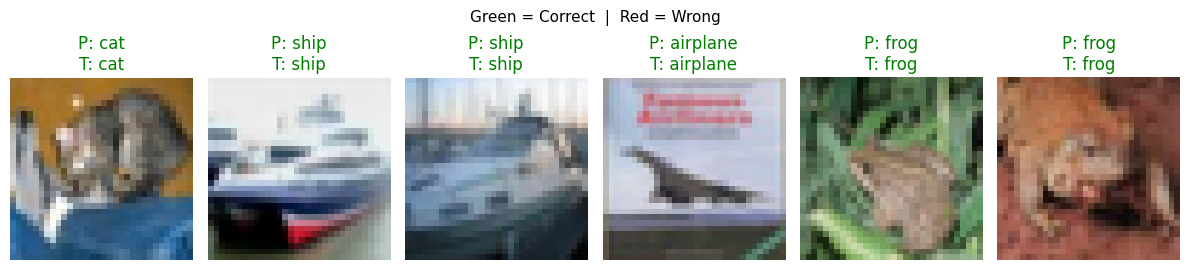

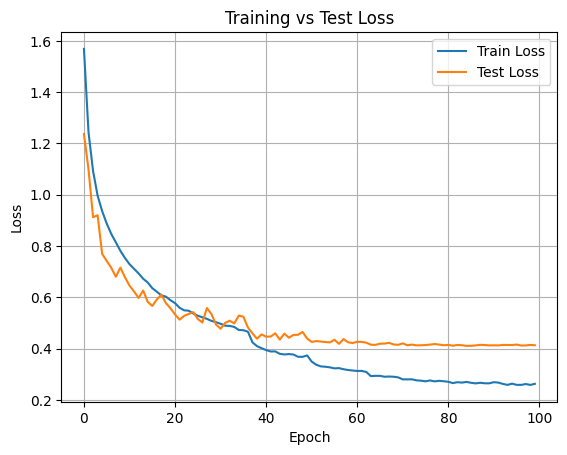

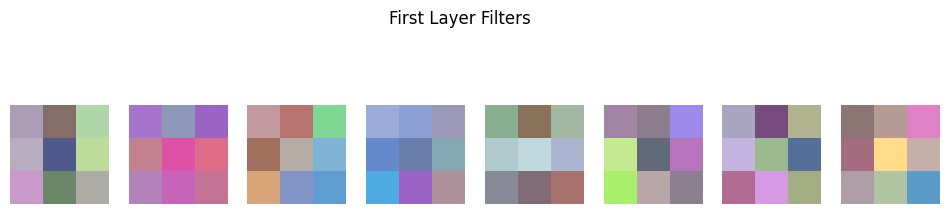

In [ ]:
# ===== CIFAR-10 CNN CLASSIFICATION WITH NORMALIZATION =====

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── Device Setting──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ── Visualisation Function ─────────────────────────────────────────────────────
def plot_loss(train_history, test_history):
    plt.figure()
    plt.plot(train_history, label="Train Loss")
    plt.plot(test_history,  label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Test Loss")
    plt.legend()
    plt.grid()
    plt.show()

def visualize_filters(model):
    filters = model.conv[0].weight.data.clone().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min())
    num_filters = min(filters.shape[0], 8)
    fig, axes = plt.subplots(1, num_filters, figsize=(12, 3))
    for i in range(num_filters):
        f = filters[i].permute(1, 2, 0)   # CHW → HWC
        axes[i].imshow(f)
        axes[i].axis('off')
    plt.suptitle("First Layer Filters")
    plt.show()

def unnormalize(img):
    return torch.clamp(img * 0.5 + 0.5, 0., 1.)   # reverse [-1,1] → [0,1]

# ── Data ──────────────────────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),              # augmentation
    transforms.RandomCrop(32, padding=4),           # augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root="./data", train=True,  download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# ── Model ─────────────────────────────────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),                     #  change for speeds convergence
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                        # -> 32×16×16

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                        # -> 64×8×8

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                        # -> 128×4×4
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),                        # this helps in reducing overfitting
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = CNN().to(device)                            # Move model to GPU

# ── Training Setup ────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # L2 regularisation
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
scaler    = torch.amp.GradScaler('cuda')            # mixed precision

# ── Training Loop ─────────────────────────────────────────────────────────────
epochs = 100
train_loss_history = []
test_loss_history  = []

for epoch in range(epochs):

    # — Train —
    model.train()
    running_loss = 0.0

    for img, label in train_loader:
        img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)

        optimizer.zero_grad()                       # Moved before forward pass

        with torch.amp.autocast('cuda'):            # Updated deprecated API
            output = model(img)
            loss   = criterion(output, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # — Validation —
    model.eval()
    test_loss = 0.0
    correct   = 0
    total     = 0

    with torch.no_grad():
        for img, label in test_loader:
            img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                output = model(img)
                loss   = criterion(output, label)
            test_loss += loss.item()
            _, predicted = torch.max(output, 1)
            total   += label.size(0)
            correct += (predicted == label).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    test_loss_history.append(avg_test_loss)
    scheduler.step(avg_test_loss)

    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} "
          f"| Test Loss: {avg_test_loss:.4f} | Acc: {100*correct/total:.2f}%")

# ── Final Evaluation + Per-Class Accuracy ────────────────────────────────────
model.eval()
class_correct = [0] * 10
class_total   = [0] * 10

with torch.no_grad():
    for img, label in test_loader:
        img, label = img.to(device, non_blocking=True), label.to(device, non_blocking=True)
        outputs = model(img)
        _, predicted = torch.max(outputs, 1)
        for c in range(10):
            mask = (label == c)
            class_correct[c] += (predicted[mask] == label[mask]).sum().item()
            class_total[c]   += mask.sum().item()

print("\nPer-Class Accuracy:")
for c in range(10):
    print(f"  {classes[c]:12s}: {100 * class_correct[c] / class_total[c]:.1f}%")
overall = 100 * sum(class_correct) / sum(class_total)
print(f"\nOverall Test Accuracy: {overall:.2f}%")

# ── Visualise Predictions ─────────────────────────────────────────────────────
images, labels = next(iter(test_loader))
images, labels = images[:6].to(device), labels[:6].to(device)

with torch.no_grad():
    _, preds = torch.max(model(images), 1)

images = images.cpu()
preds  = preds.cpu()
labels = labels.cpu()

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img = unnormalize(images[i]).permute(1, 2, 0)
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f"P: {classes[preds[i]]}\nT: {classes[labels[i]]}", color=color)
    axes[i].axis('off')

plt.suptitle("Green = Correct  |  Red = Wrong", fontsize=11)
plt.tight_layout()
plt.show()

plot_loss(train_loss_history, test_loss_history)
visualize_filters(model)

In [ ]:
  ### CNN autoencoder training on on handwritten digits (MNIST datasets)

Using device: cuda
Epoch  1/50, Loss: 0.0204
Epoch  2/50, Loss: 0.0033
Epoch  3/50, Loss: 0.0030
Epoch  4/50, Loss: 0.0028
Epoch  5/50, Loss: 0.0028
Epoch  6/50, Loss: 0.0027
Epoch  7/50, Loss: 0.0027
Epoch  8/50, Loss: 0.0026
Epoch  9/50, Loss: 0.0026
Epoch 10/50, Loss: 0.0026
Epoch 11/50, Loss: 0.0026
Epoch 12/50, Loss: 0.0026
Epoch 13/50, Loss: 0.0025
Epoch 14/50, Loss: 0.0025
Epoch 15/50, Loss: 0.0025
Epoch 16/50, Loss: 0.0025
Epoch 17/50, Loss: 0.0025
Epoch 18/50, Loss: 0.0025
Epoch 19/50, Loss: 0.0025
Epoch 20/50, Loss: 0.0025
Epoch 21/50, Loss: 0.0025
Epoch 22/50, Loss: 0.0025
Epoch 23/50, Loss: 0.0025
Epoch 24/50, Loss: 0.0025
Epoch 25/50, Loss: 0.0025
Epoch 26/50, Loss: 0.0025
Epoch 27/50, Loss: 0.0025
Epoch 28/50, Loss: 0.0025
Epoch 29/50, Loss: 0.0025
Epoch 30/50, Loss: 0.0024
Epoch 31/50, Loss: 0.0024
Epoch 32/50, Loss: 0.0024
Epoch 33/50, Loss: 0.0024
Epoch 34/50, Loss: 0.0024
Epoch 35/50, Loss: 0.0024
Epoch 36/50, Loss: 0.0024
Epoch 37/50, Loss: 0.0024
Epoch 38/50, Loss: 

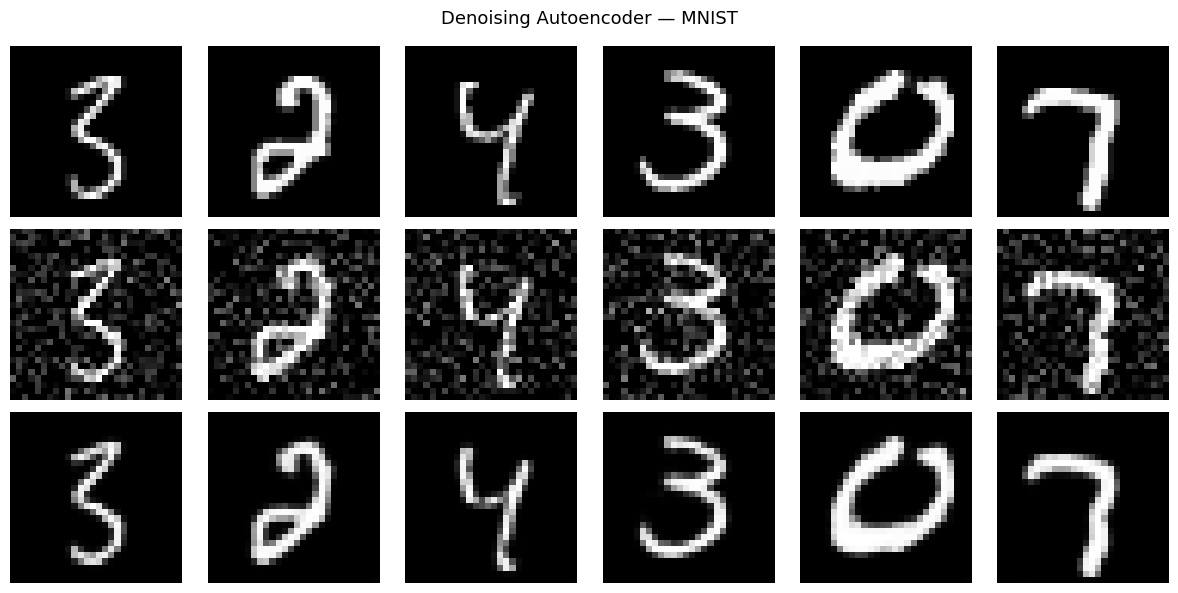

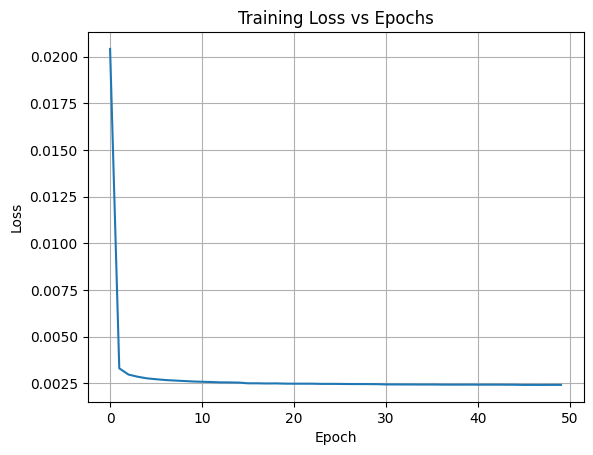

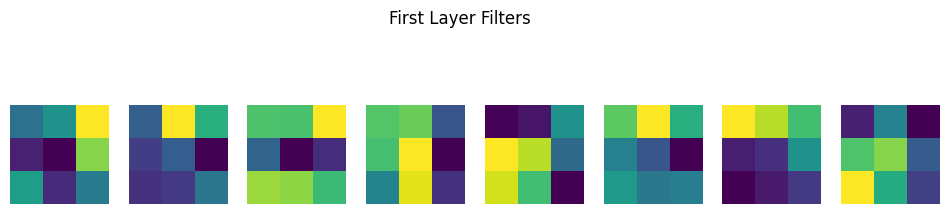

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── Device Setting──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ── Visualisation ─────────────────────────────────────────────────────
def plot_loss(loss_history):
    plt.figure()
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss vs Epochs")
    plt.grid()
    plt.show()

def visualize_filters(model):
    filters = model.encoder[0].weight.data.clone().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min())
    num_filters = min(filters.shape[0], 8)
    fig, axes = plt.subplots(1, num_filters, figsize=(12, 3))
    for i in range(num_filters):
        f = filters[i].permute(1, 2, 0)
        axes[i].imshow(f.squeeze(), cmap='viridis')
        axes[i].axis('off')
    plt.suptitle("First Layer Filters")
    plt.show()

# ── Data ──────────────────────────────────────────────────────────────────────
transform = transforms.ToTensor()

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ── Model ─────────────────────────────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: 1×28×28 -> 64×7×7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),   # → 32×14×14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # → 64×7×7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Decoder: 64×7×7 -> 1×28×28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # → 32×14×14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),   # → 1×28×28
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder().to(device)

# ── Noise ─────────────────────────────────────────────────────────────────────
def add_noise(x, std=0.2):                      # Choose carefully (0.1-1.0)
    return torch.clamp(x + torch.randn_like(x) * std, 0., 1.)

# ── Training Setup ────────────────────────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler    = torch.amp.GradScaler('cuda')        # updated deprecated API
epochs    = 50
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

# ── Training Loop ─────────────────────────────────────────────────────────────
loss_history = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for img, _ in loader:
        img   = img.to(device, non_blocking=True)
        noisy = add_noise(img)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):        # use updated deprecated API
            output = model(noisy)
            loss   = criterion(output, img)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{epochs}, Loss: {avg_loss:.4f}")

# ── Evaluation ────────────────────────────────────────────────────────────────
model.eval()
images, _ = next(iter(loader))
images       = images[:6].to(device)
noisy_images = add_noise(images)

with torch.no_grad():
    outputs = model(noisy_images)

images       = images.cpu()
noisy_images = noisy_images.cpu()
outputs      = outputs.cpu()

# ── Visualise Results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
row_labels = ["Original", "Noisy", "Reconstructed"]

for i in range(6):
    axes[0, i].imshow(images[i].squeeze(),       cmap='gray')
    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[2, i].imshow(outputs[i].squeeze(),      cmap='gray')
    for row in range(3):
        axes[row, i].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11)

plt.suptitle("Denoising Autoencoder — MNIST", fontsize=13)
plt.tight_layout()
plt.show()

plot_loss(loss_history)
visualize_filters(model)